In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import plotly.graph_objects as go
from utils import metrics
from scipy import stats
from tqdm import tqdm

In [14]:
def get_component_hists(img):
    r_hist, _ = np.histogram(img[:,0], bins=255, range=(0, 255))
    g_hist, _ = np.histogram(img[:,1], bins=255, range=(0, 255))
    b_hist, _ = np.histogram(img[:,2], bins=255, range=(0, 255))
    r_hist_norm = r_hist / (np.sum(r_hist) + 1e-10)
    g_hist_norm = g_hist / (np.sum(g_hist) + 1e-10)
    b_hist_norm = b_hist / (np.sum(b_hist) + 1e-10)
    return (r_hist_norm, g_hist_norm, b_hist_norm)

def line_difference_horizontal_aux(img, start_coords : tuple, direction : tuple, thresh : float) -> tuple:
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_lab = img_lab.astype('float')
    img_hsv = img_hsv.astype('float')
    current_y = start_coords[0]
    current_x = start_coords[1]
    
    hist_l, hist_a, hist_b = get_component_hists(img_lab[:, current_x])
    hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[:, current_x + direction[1]])
    
    hist_h, hist_s, hist_v = get_component_hists(img_hsv[:, current_x])
    hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[:, current_x + direction[1]])
    
    
    difference = np.sum([
                  metrics.earth_movers_distance(hist_a, hist_new_a) * 0.45,
                  metrics.earth_movers_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
    
    while difference < thresh:
        current_x += direction[1]
        hist_l, hist_a, hist_b = get_component_hists(img_lab[:, current_x])
        hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[:, current_x + direction[1]])
        
        hist_h, hist_s, hist_v = get_component_hists(img_hsv[:, current_x])
        hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[:, current_x + direction[1]])
        
        difference = np.sum([
                  metrics.earth_movers_distance(hist_a, hist_new_a) * 0.45,
                  metrics.earth_movers_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
        
    
    return (current_y, current_x)

def line_difference_horizontal_aux2(img, start_coords : tuple, direction : tuple, thresh : float) -> tuple:
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_lab = img_lab.astype('float')
    img_hsv = img_hsv.astype('float')
    current_y = start_coords[0]
    current_x = start_coords[1]
    diff_image = 0.45*img_lab[:, :, 1] + 0.45*img_lab[:, :, 2] + 0.1*img_hsv[:, :, 1]
    
    difference = np.abs(diff_image[current_y, current_x] - diff_image[current_y, current_x + direction[1]])
    
    while difference < thresh:
        current_x += direction[1]
        difference = np.abs(diff_image[current_y, current_x] - diff_image[current_y, current_x + direction[1]])
        
    return (current_y, current_x)

def line_difference(diff_image, start_coords : tuple, direction : tuple, thresh : float) -> tuple:
    
    current_y = start_coords[0]
    current_x = start_coords[1]
    difference = diff_image[current_y, current_x]
    
    while difference < thresh:
        current_y += direction[0]
        current_x += direction[1]
        if current_x == 0 or current_x >= diff_image.shape[1] - 1 or current_y == 0 or current_y >= diff_image.shape[0] - 1:
            return (current_y, current_x)
        difference = np.abs(diff_image[current_y, current_x])
        #print(difference)
    
    return (current_y, current_x)

def line_difference_horizontal(img, start_coords : tuple, direction : tuple) -> tuple:
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_lab = img_lab.astype('float')
    img_hsv = img_hsv.astype('float')
    current_y = start_coords[0]
    current_x = start_coords[1]
    
    hist_l, hist_a, hist_b = get_component_hists(img_lab[:, current_x])
    hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[:, current_x + direction[1]])
    
    hist_h, hist_s, hist_v = get_component_hists(img_hsv[:, current_x])
    hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[:, current_x + direction[1]])
    
    difference = np.sum([
                  metrics.canberra_distance(hist_a, hist_new_a) * 0.45,
                  metrics.canberra_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
    
    while difference < THRESHOLD_HORIZONTAL:
        current_x += direction[1]
        hist_l, hist_a, hist_b = get_component_hists(img_lab[:, current_x])
        hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[:, current_x + direction[1]])
        
        hist_h, hist_s, hist_v = get_component_hists(img_hsv[:, current_x])
        hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[:, current_x + direction[1]])
        
        difference = np.sum([
                    metrics.canberra_distance(hist_a, hist_new_a) * 0.45,
                    metrics.canberra_distance(hist_b, hist_new_b) * 0.45,
                    metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
        #print(difference)
    
    return (current_y, current_x)

def line_difference_vertical(img, start_coords : tuple, direction : tuple, thresh : float) -> tuple:
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_lab = img_lab.astype('float')
    img_hsv = img_hsv.astype('float')
    current_y = start_coords[0]
    current_x = start_coords[1]
    
    hist_l, hist_a, hist_b = get_component_hists(img_lab[current_y])
    hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[current_y + direction[0]])
    
    hist_h, hist_s, hist_v = get_component_hists(img_hsv[current_y])
    hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[current_y + direction[0]])
    
    difference = np.sum([
                  metrics.earth_movers_distance(hist_a, hist_new_a) * 0.45,
                  metrics.earth_movers_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
    
    while difference < thresh and current_y >= 0 and current_y < img.shape[0]:
        current_y += direction[0]
        hist_l, hist_a, hist_b = get_component_hists(img_lab[current_y])
        hist_new_l, hist_new_a, hist_new_b = get_component_hists(img_lab[current_y + direction[0]])
        
        hist_h, hist_s, hist_v = get_component_hists(img_hsv[current_y])
        hist_new_h, hist_new_s, hist_new_bv= get_component_hists(img_hsv[current_y + direction[0]])
        
        difference = np.sum([
                  metrics.earth_movers_distance(hist_a, hist_new_a) * 0.45,
                  metrics.earth_movers_distance(hist_b, hist_new_b) * 0.45,
                  metrics.canberra_distance(hist_s, hist_new_s) * 0.1])
        #print(difference)
    
    return (current_y, current_x)

def get_histogram_peak(img, n_bins=255, n_range=(0, 256)):
    img = img.astype(np.uint8)
    weights = (img != 0).astype(int)
    hist, _ = np.histogram(img, bins=n_bins, range=n_range, weights=weights)
    hist = hist.astype(np.float32)
    hist /= np.sum(hist)

    smooth_hist = gaussian_filter1d(hist, sigma=4)
    main_peak = np.argmax(smooth_hist)
    threshold = smooth_hist[main_peak] * 0.8
    

    left = main_peak
    while left > 0 and smooth_hist[left] > smooth_hist[left - 1]:
        left -= 1
        
    right = main_peak
    while right < len(smooth_hist) - 1 and smooth_hist[right] > smooth_hist[right + 1]:
        right += 1
        
    plt.bar(range(len(smooth_hist)), smooth_hist)
    plt.axvline(left)
    plt.axvline(right)
    plt.show()
        
    return (left, right)

def get_histogram_peaks(img) -> list:
    img = img.astype(np.uint8)
    r, g, b = img[:, :, 0], img[:, :, 1], img[:, :, 2]
    
    left_r, right_r = get_histogram_peak(r)
    left_g, right_g = get_histogram_peak(g)
    left_b, right_b = get_histogram_peak(b)
    
    return (left_r, right_r), (left_g, right_g), (left_b, right_b)

def hist_remove_borders(img):
    top_border = img.copy()

    top_lab = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(top_lab)
    left, right = get_histogram_peak(s)

    top_border[(s < left) | (s > right)] = 0
    return top_border

def compute_vertical_line(point1, point2):
    
    A = point1[1] - point2[1]
    B = point2[0] - point1[0]
    C = point1[0]*point2[1] - point2[0]*point1[1]
    
    if B != 0:
        m = -A / B
        b = -C / B
    else:
        m = 0
        b = -C/A
    
    def line_func(x):
        return m*x + b
    
    return line_func

def compute_horizontal_line(point1, point2):
    
    A = point1[0] - point2[0]
    B = point2[1] - point1[1]
    C = point1[1]*point2[0] - point2[1]*point1[0]
    
    if B != 0:
        m = -A / B
        b = -C / B
    else:
        m = 0
        b = -C/A
    
    def line_func(x):
        return m*x + b
    
    return line_func

In [15]:
def get_borders(img):
    
    middle_x = img.shape[1]//2
    middle_y = img.shape[0]//2
    threshold_vert = 7
    

    #We look from the top
    top_point_left = line_difference_vertical(
        img, start_coords=(0, middle_y), direction=(1,0), thresh=threshold_vert)
    
    bottom_point_left = line_difference_vertical(
        img, start_coords=(img.shape[0] - 1, middle_y), direction=(-1, 0), thresh=threshold_vert)
    
    threshold_hor = 4
    
    left_point = line_difference_horizontal_aux(
        img, start_coords=(top_point_left[0], 0), direction=(0, 1), thresh=threshold_hor
    )
    
    right_point = line_difference_horizontal_aux(
        img, start_coords=(top_point_left[0], img.shape[1] - 1), direction=(0, -1), thresh=threshold_hor
    )
        

    return top_point_left, bottom_point_left, left_point, right_point

In [16]:
def compute_vertical_side(img, start_coords : tuple, end_coords : tuple, direction : tuple, ray_direction : tuple):
    
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype('float')
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV_FULL).astype(float)
    diff_image = img_hsv[:, :, 1]
    
    
    def_diff_image = np.abs(diff_image[1:diff_image.shape[0], :] - diff_image[:diff_image.shape[0] - 1, :])
    
    points = []
    current_x = start_coords[1]
    current_y = start_coords[0]
    threshold = 2
    
    while current_x <= end_coords[1] and current_y <= end_coords[0]:
        points.append(line_difference(def_diff_image, start_coords=(current_y, current_x), direction=ray_direction, thresh=threshold))
        current_x += direction[1]
        current_y += direction[0]

    
    return np.array(points)

def compute_bottom_side(img, start_coords : tuple, direction : tuple, ray_direction : tuple):
    
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype('float')
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV_FULL).astype(float)
    diff_image = 0.2*img_lab[:,:,1] + 0.2*img_lab[:, :,2] + 0.6*img_hsv[:, :, 1]
    
    def_diff_image = np.abs(diff_image[:, 1:(img.shape[1])] - diff_image[:, :(img.shape[1] - 1)])
    
    """plt.imshow(def_diff_image),
    plt.show()"""
    
    points = []
    current_x = start_coords[1]
    current_y = start_coords[0]
    threshold = 4
    
    while current_x < def_diff_image.shape[1] and current_y < def_diff_image.shape[0]:
        points.append(line_difference(def_diff_image, start_coords=(current_y, current_x), direction=ray_direction, thresh=threshold))
        current_x += direction[1]
        current_y += direction[0]

    
    return np.array(points)

Correct bottom: 228
Correct left: 3
Correct right: 267


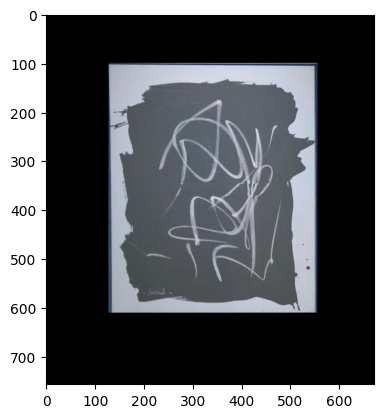

In [17]:
img = cv2.imread("data/qsd2_w1/00021.jpg", cv2.IMREAD_UNCHANGED)
middle_y = img.shape[0] // 2
shift_y = middle_y // 4

# Get points by whole row/column aware methods
top_point, bottom_point, left_point, right_point = get_borders(img)

#Combine row aware with ray throw to get a corrected bottom side
bottom_side = compute_bottom_side(img, (img.shape[0] - 1, 0), (0, 1), (-1, 0))
bottom_median= int(np.median(bottom_side[:, 0]))

correct_values = bottom_side[(bottom_side[:,0] <= bottom_point[0] +10) & (bottom_side[:, 0] >= bottom_median - 10)]
corrected_median = int(np.median(correct_values[:, 0])) if len(correct_values) > 0 else bottom_point[0]

print(f"Correct bottom: {len(correct_values)}")

border_image = img.copy()

border_image[range(img.shape[0] - 1, corrected_median, -1), :, :] = 0
border_image[range(top_point[0]), :, :] = 0

left_side = compute_vertical_side(img, (top_point[0], 0), (corrected_median, 0), (1, 0), (0, 1))
left_median = int(np.median(left_side[:, 1]))
correct_left_values = left_side[(left_side[:,1] >= left_point[1] - 10) & (left_side[:, 1] <= left_median - 10)]
corrected_left_median = int(np.median(correct_left_values[:, 1])) if len(correct_left_values) > 0 else left_point[1]
print(f"Correct left: {len(correct_left_values)}")

right_side = compute_vertical_side(img, (top_point[0], img.shape[1] - 1), (corrected_median, img.shape[1] - 1), (1, 0), (0, -1))
right_median = int(np.median(right_side[:, 1]))
correct_right_values = right_side[(right_side[:,1] <= right_point[1] +10) & (right_side[:, 1] >= right_median - 10)]
corrected_right_median = int(np.median(correct_right_values[:, 1])) if len(correct_right_values) > 0 else right_point[1]

print(f"Correct right: {len(correct_right_values)}")

border_image[:, range(left_median), :] = 0
border_image[:, range(img.shape[1] - 1, corrected_right_median, -1), :] = 0

plt.imshow(border_image)
plt.show()

  0%|          | 0/30 [00:00<?, ?it/s]

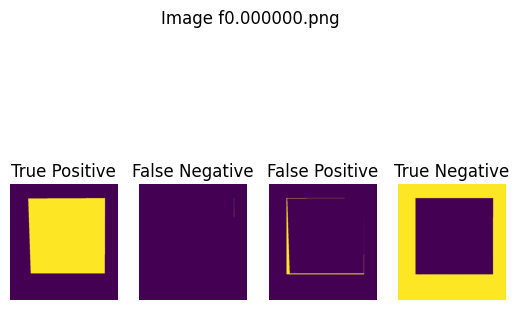

  3%|▎         | 1/30 [00:00<00:17,  1.70it/s]

Precision: 0.9597295559439717
Recall: 0.9995739957736488
F_score: 0.9792466371594114


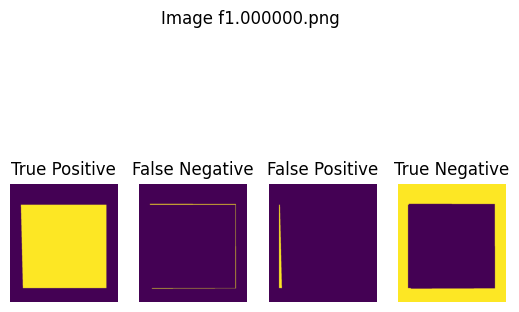

  7%|▋         | 2/30 [00:01<00:20,  1.39it/s]

Precision: 0.9784036469492722
Recall: 0.9800555633587673
F_score: 0.979228908476803


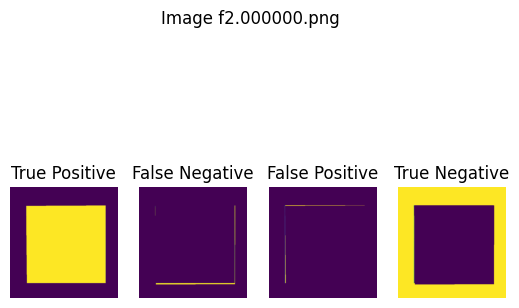

 10%|█         | 3/30 [00:01<00:15,  1.70it/s]

Precision: 0.9909222870560027
Recall: 0.9784023842596365
F_score: 0.9846225382672944


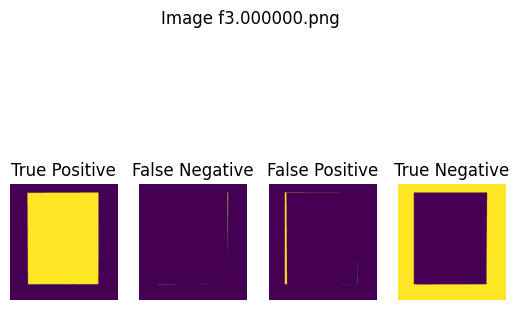

 13%|█▎        | 4/30 [00:02<00:17,  1.52it/s]

Precision: 0.9723861872438412
Recall: 0.9958371566874578
F_score: 0.9839719652678447


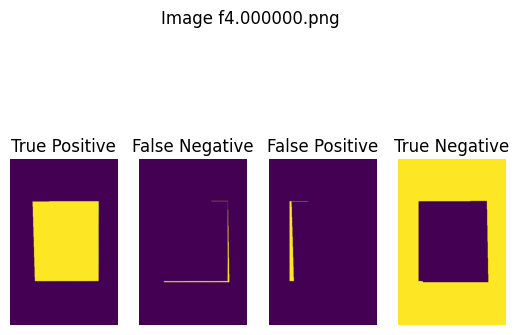

 17%|█▋        | 5/30 [00:03<00:14,  1.74it/s]

Precision: 0.9526620216927039
Recall: 0.9718675483316728
F_score: 0.9621689558133999


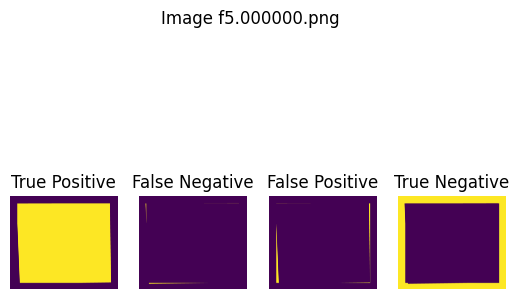

 20%|██        | 6/30 [00:04<00:23,  1.01it/s]

Precision: 0.9808456515163935
Recall: 0.9948672094247739
F_score: 0.9878066752429732


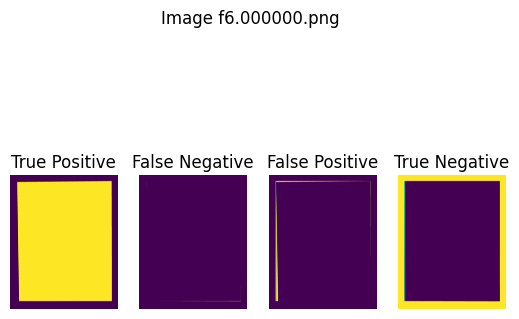

 23%|██▎       | 7/30 [00:07<00:32,  1.41s/it]

Precision: 0.980970243777886
Recall: 0.9989790630990102
F_score: 0.9898927529644777


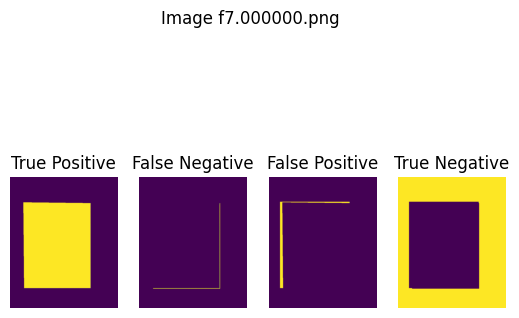

 27%|██▋       | 8/30 [00:07<00:25,  1.15s/it]

Precision: 0.950429379466162
Recall: 0.9857358341820962
F_score: 0.9677606958281508


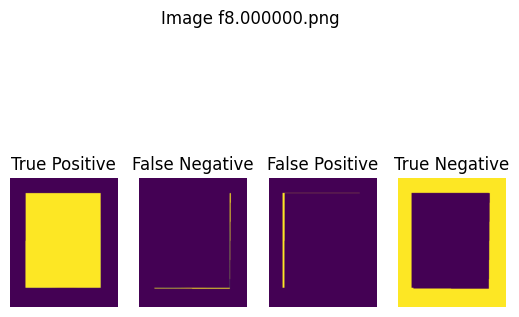

 30%|███       | 9/30 [00:08<00:20,  1.04it/s]

Precision: 0.9723996214636308
Recall: 0.9832543969683505
F_score: 0.9777968847281857


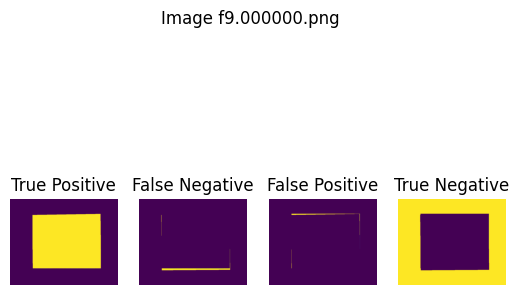

 33%|███▎      | 10/30 [00:08<00:16,  1.19it/s]

Precision: 0.9852518822110036
Recall: 0.9670081846552435
F_score: 0.9760447905635502


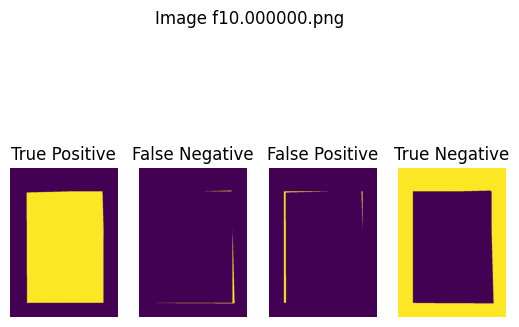

 37%|███▋      | 11/30 [00:09<00:14,  1.35it/s]

Precision: 0.9703450004122017
Recall: 0.9859854462738705
F_score: 0.9781027023238581


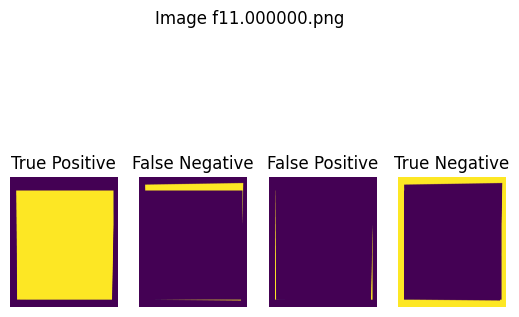

 40%|████      | 12/30 [00:11<00:21,  1.21s/it]

Precision: 0.9876564041111696
Recall: 0.9371534048323517
F_score: 0.9617423577296603


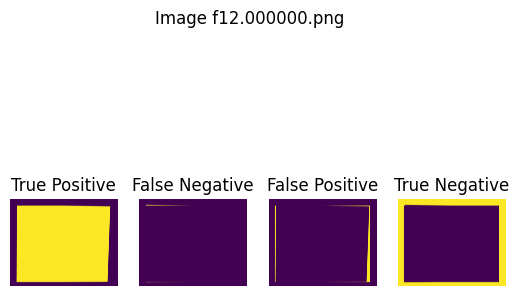

 43%|████▎     | 13/30 [00:13<00:22,  1.33s/it]

Precision: 0.9654339410445006
Recall: 0.9969214998027214
F_score: 0.9809250989219416


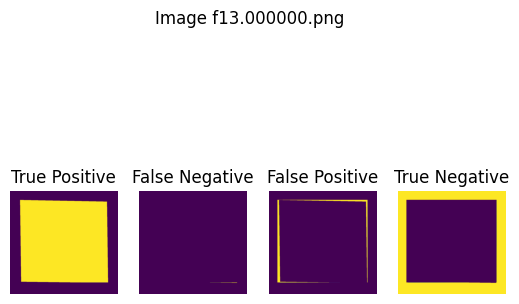

 47%|████▋     | 14/30 [00:13<00:17,  1.08s/it]

Precision: 0.9508970423948582
Recall: 0.9991282542656765
F_score: 0.9744161817607024


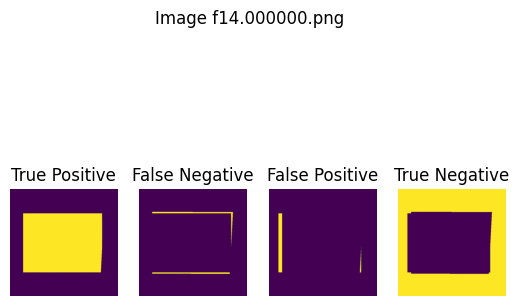

 50%|█████     | 15/30 [00:14<00:13,  1.13it/s]

Precision: 0.951729824614653
Recall: 0.9490055226004059
F_score: 0.9503657212522277


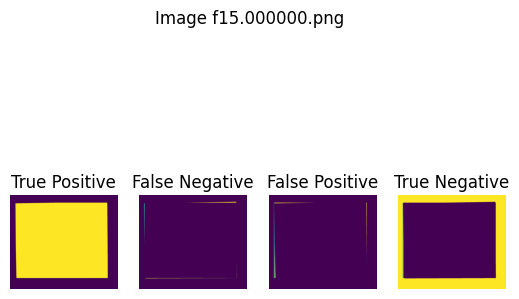

 53%|█████▎    | 16/30 [00:15<00:13,  1.02it/s]

Precision: 0.9908895081907919
Recall: 0.9928672546567988
F_score: 0.9918773955466059


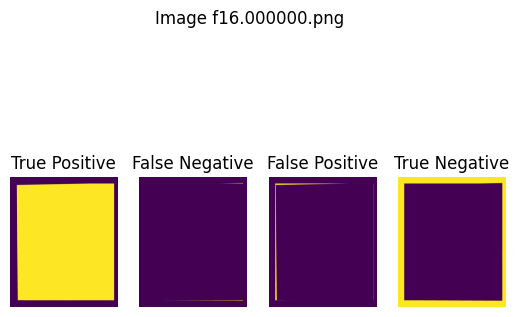

 57%|█████▋    | 17/30 [00:17<00:16,  1.25s/it]

Precision: 0.983932205898251
Recall: 0.9979389658349657
F_score: 0.9908860898835387


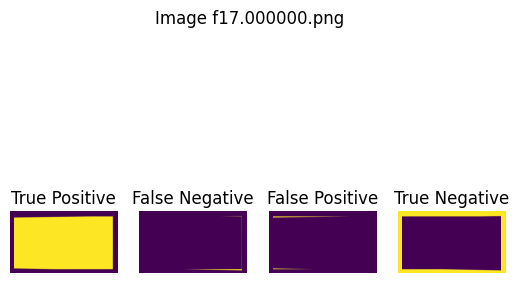

 60%|██████    | 18/30 [00:19<00:17,  1.46s/it]

Precision: 0.985924473328109
Recall: 0.9866840355787884
F_score: 0.9863041082169274


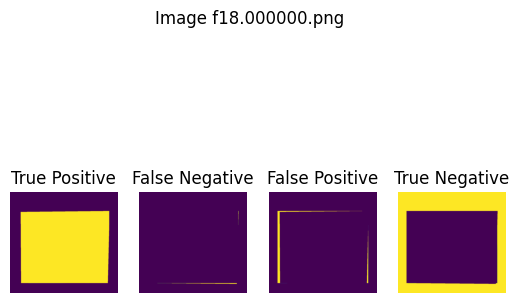

 63%|██████▎   | 19/30 [00:19<00:13,  1.19s/it]

Precision: 0.9619463276441251
Recall: 0.9941731918198521
F_score: 0.9777942926262553


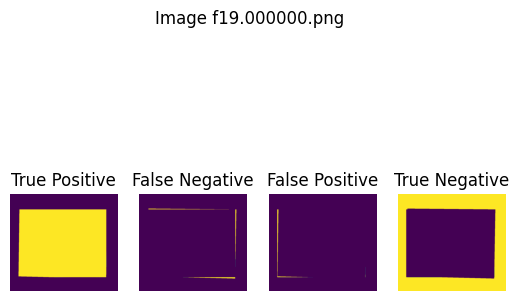

 67%|██████▋   | 20/30 [00:20<00:10,  1.01s/it]

Precision: 0.9892484367619312
Recall: 0.9828891561783523
F_score: 0.986058543521847


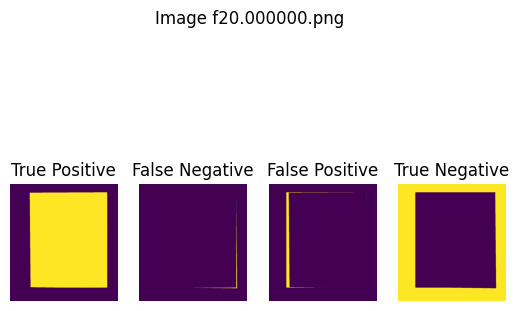

 70%|███████   | 21/30 [00:21<00:08,  1.09it/s]

Precision: 0.9614956936614427
Recall: 0.9924191171610425
F_score: 0.9767127022861014


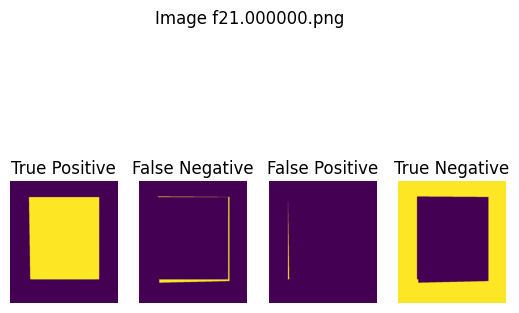

 73%|███████▎  | 22/30 [00:21<00:06,  1.15it/s]

Precision: 0.991148111548722
Recall: 0.9494797834852441
F_score: 0.9698666053015977


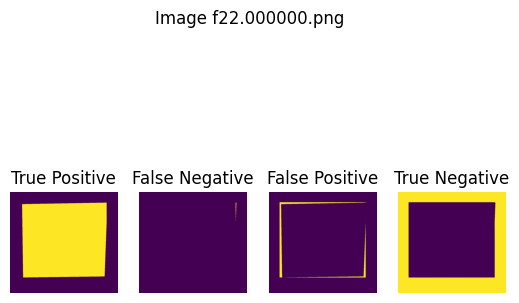

 77%|███████▋  | 23/30 [00:22<00:05,  1.24it/s]

Precision: 0.9458598549567915
Recall: 0.9987875378722918
F_score: 0.97160342711813


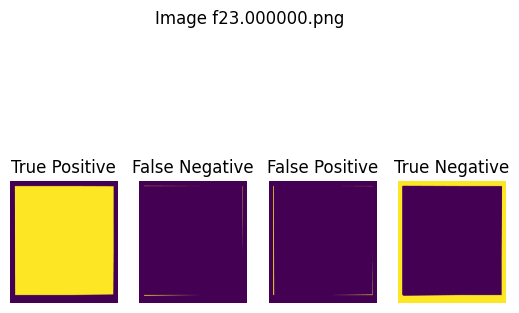

 80%|████████  | 24/30 [00:24<00:07,  1.19s/it]

Precision: 0.9906239258387217
Recall: 0.9957636533438329
F_score: 0.993187140133965


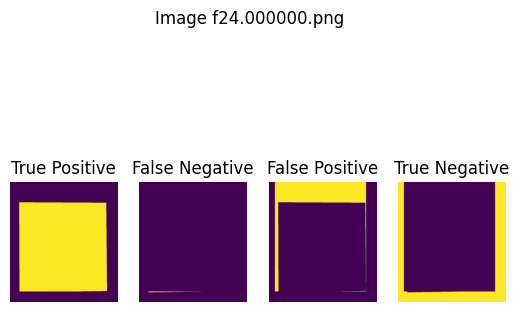

 83%|████████▎ | 25/30 [00:25<00:04,  1.00it/s]

Precision: 0.7761311353862274
Recall: 0.9967879061121184
F_score: 0.8727280955324779


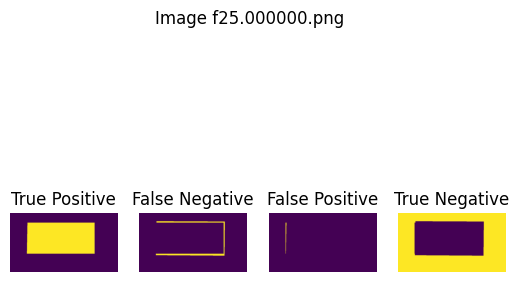

 87%|████████▋ | 26/30 [00:25<00:03,  1.19it/s]

Precision: 0.9910527195595694
Recall: 0.8980651621635202
F_score: 0.9422703897038487


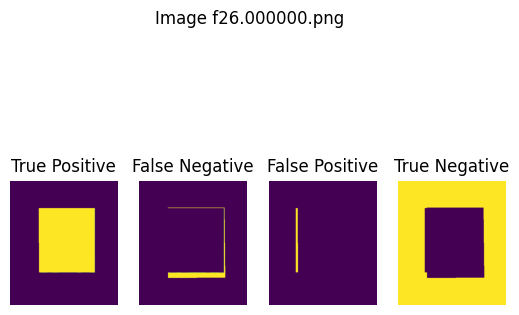

 90%|█████████ | 27/30 [00:26<00:02,  1.38it/s]

Precision: 0.9633327072625923
Recall: 0.9002485879945537
F_score: 0.9307229168797314


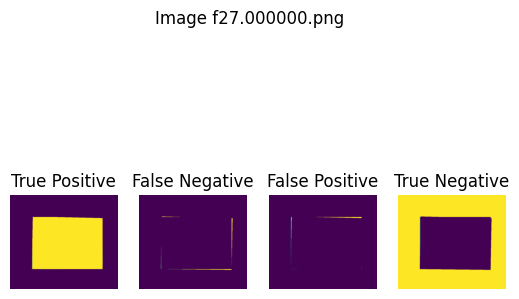

 93%|█████████▎| 28/30 [00:26<00:01,  1.43it/s]

Precision: 0.9890166518011319
Recall: 0.9835471517545046
F_score: 0.9862743188974302


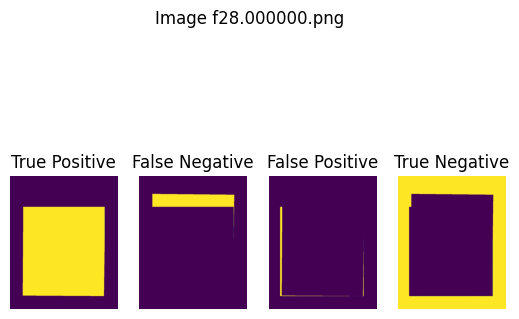

 97%|█████████▋| 29/30 [00:27<00:00,  1.38it/s]

Precision: 0.971813780620404
Recall: 0.875508486632771
F_score: 0.9211508218595359


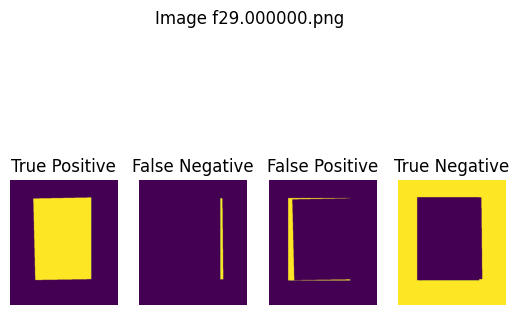

100%|██████████| 30/30 [00:27<00:00,  1.07it/s]

Precision: 0.9017576051022265
Recall: 0.9574914936732631
F_score: 0.9287891943142114
0.9686772969374228
0.9648078609153093
0.9742142316259194


In [18]:
score = 0
precision = 0
recall = 0

for i in tqdm(range(30)):
    img = cv2.imread(f"data/qsd2_w1/{i:05d}.jpg", cv2.IMREAD_UNCHANGED)
    correct_img = cv2.imread(f"data/qsd2_w1/{i:05d}.png", cv2.IMREAD_UNCHANGED)
    middle_y = img.shape[0] // 2
    shift_y = middle_y // 4

    # Get points by whole row/column aware methods
    top_point, bottom_point, left_point, right_point = get_borders(img)

    #Combine row aware with ray throw to get a corrected bottom side
    bottom_side = compute_bottom_side(img, (img.shape[0] - 1, 0), (0, 1), (-1, 0))
    bottom_median= int(np.median(bottom_side[:, 0]))

    correct_values = bottom_side[(bottom_side[:,0] <= bottom_point[0] +10) & (bottom_side[:, 0] >= bottom_median - 10)]
    corrected_median = int(np.median(correct_values[:, 0])) if len(correct_values) > 0 else bottom_point[0]

    border_image = img.copy()

    border_image[range(img.shape[0] - 1, corrected_median, -1), :, :] = 0
    border_image[range(top_point[0]), :, :] = 0

    left_side = compute_vertical_side(img, (top_point[0], 0), (corrected_median, 0), (1, 0), (0, 1))
    left_median = int(np.median(left_side[:, 1]))
    correct_left_values = left_side[(left_side[:,1] >= left_point[1] - 10) & (left_side[:, 1] <= left_median - 10)]
    corrected_left_median = int(np.median(correct_left_values[:, 1])) if len(correct_left_values) > 0 else left_point[1]

    right_side = compute_vertical_side(img, (top_point[0], img.shape[1] - 1), (corrected_median, img.shape[1] - 1), (1, 0), (0, -1))
    right_median = int(np.median(right_side[:, 1]))
    correct_right_values = right_side[(right_side[:,1] <= right_point[1] +10) & (right_side[:, 1] >= right_median - 10)]
    corrected_right_median = int(np.median(correct_right_values[:, 1])) if len(correct_right_values) > 0 else right_point[1]

    border_image[:, range(left_median), :] = 0
    border_image[:, range(img.shape[1] - 1, corrected_right_median, -1), :] = 0
    
    """f, ax = plt.subplots(1, 2)
    f.suptitle(f"Image f{i:05f}.png")
    plt.axis('off')
    ax[0].imshow(border_image)
    ax[0].axis('off')"""
    
    border_image[top_point[0]:corrected_median, corrected_left_median:corrected_right_median, :] = 255
    
    """ax[1].imshow(border_image)
    ax[1].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 1.2])
    plt.show()"""
    
    result = border_image[:, :, 0]
    
    
    TP = np.sum(correct_img & result)
    FN = np.sum(correct_img & (255 - result))
    FP = np.sum((255 - correct_img) & result)
    TN = np.sum((255 - correct_img) & (255 - result))
    
    f, ax = plt.subplots(1, 4)
    f.suptitle(f"Image f{i:05f}.png")
    plt.axis('off')
    ax[0].imshow(correct_img & result)
    ax[0].axis('off')
    ax[0].set_title("True Positive")
    
    ax[1].imshow(correct_img & (255 - result))
    ax[1].axis('off')
    ax[1].set_title("False Negative")
    
    ax[2].imshow((255 - correct_img) & result)
    ax[2].axis('off')
    ax[2].set_title("False Positive")
    
    ax[3].imshow((255 - correct_img) & (255 - result))
    ax[3].axis('off')
    ax[3].set_title("True Negative")
    
    plt.show()
    
    
    P = TP / (TP + FP)
    R = TP / (TP + FN)
    F_score = 2*(P*R/(P + R))
    
    score = score + F_score
    precision += P
    recall += R
    
    print(f"Precision: {P}\nRecall: {R}\nF_score: {F_score}")
    
print(score/30)
print(precision/30)
print(recall/30)
    